In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pyfonts import load_google_font

# Population (1890) - color

In [2]:
# Load color df
ga1890_pop = pd.read_csv("ga1890pop.csv")

In [3]:
# Rows and columns
ga1890_pop.shape

(199, 2)

In [4]:
ga1890_pop.head(2)

,APPLING01,gold
0,APPLING02,gold
1,BAKER01,pink


In [5]:
# Select object datatype columns
df_obj = ga1890_pop.select_dtypes("object")
# Remove trailing white spaces in object datatype columns
ga1890_pop[df_obj.columns] = df_obj.apply(lambda x: x.str.strip())
# Rename a column
ga1890_pop.rename(columns={"gold": "color"}, inplace=True)

In [6]:
# Remove last 2 characters in each row of a column
ga1890_pop["APPLING"] = ga1890_pop["APPLING01"].str[:-2]
# Drop column
ga1890_pop = ga1890_pop.drop("APPLING01", axis=1)

In [7]:
# Drop duplicate rows in a specific column by keeping just the first occurrence
ga1890_pop.drop_duplicates(subset=["APPLING"], keep="first", inplace=True)

In [8]:
# Rows and columns
ga1890_pop.shape

(137, 2)

In [9]:
# Color dictionary
color_dict = {
    "gold": "#edb921",
    "pink": "#e2b6ad",
    "crimson": "#d32b45",
    "blue": "#242266",
    "green": "#3b513b",
    "black": "#1f1e18",
    "tan": "#c9b19b",
    "chocolate": "#3d2612"
}

# Apply color mapping
ga1890_pop["color"] = ga1890_pop["color"].map(color_dict)

In [13]:
ga1890_pop.head(2)

,color,APPLING
0,#edb921,APPLING
1,#e2b6ad,BAKER


# Data (pop ranges)

In [10]:
# Load population dfata
data = pd.read_csv("data.csv")

In [11]:
# Rows and columns
data.shape

(139, 2)

In [14]:
data.head(2)

,County,Population
0,APPLING,1000 - 2500
1,BAKER,2500 - 5000


In [15]:
# Unique entries in population column
data["Population"].unique()

array(['1000 - 2500', '2500 - 5000', '5000 - 10000', '20000 - 30000',
       '> 1000', '> 30000', '10000 - 15000', '15000 - 20000'],
      dtype=object)

In [16]:
# Population dictionary
pop_dict = {
    "1000 - 2500": "1.000 TO 2.500",
    "2500 - 5000": "2.500 TO 5.000",
    "5000 - 10000": "5.000 TO 10.000",
    "20000 - 30000": "BETWEEN 20.000 AND 30.000",
    "> 1000": "UNDER 1.000",
    "> 30000": "OVER 30.000 NEGROS",
    "10000 - 15000": "10.000 TO 15.000",
    "15000 - 20000": "15.000 TO 20.000"
}

# Apply population mapping
data["Population"] = data["Population"].map(pop_dict)

In [17]:
data.head(2)

,County,Population
0,APPLING,1.000 TO 2.500
1,BAKER,2.500 TO 5.000


# Merge of pop and data

In [18]:
# Merge dfs
df = pd.merge(ga1890_pop, data, left_on="APPLING", right_on="County", how="left")

In [19]:
# Rows and columns
df.shape

(137, 4)

In [20]:
df.head(2)

,color,APPLING,County,Population
0,#edb921,APPLING,APPLING,1.000 TO 2.500
1,#e2b6ad,BAKER,BAKER,2.500 TO 5.000


# Map

In [21]:
# Load Georgia shape file
georgia = gpd.read_file("shapefiles/DuBoisChallenge - Georgia Counties w 1870 & 1880 data.shp")

In [22]:
# Rows and columns
georgia.shape

(137, 16)

In [23]:
# Select relevant columns
georgia = georgia[["ICPSRNAM", "geometry"]]

In [24]:
georgia.head(2)

,ICPSRNAM,geometry
0,APPLING,"POLYGON ((1310135.815 -537927.898, 1310122.449..."
1,BAKER,"POLYGON ((1090472.791 -651587.102, 1090472.696..."


# Merge georgia with df

In [25]:
# Merge Georgia shape file with df
gdf = pd.merge(georgia, df, left_on="ICPSRNAM", right_on="County")

In [21]:
# Rows and columns
gdf.shape

(137, 6)

In [26]:
# Select relevant columns
gdf = gdf[["County", "Population", "color", "geometry"]]

In [27]:
gdf.head(2)

,County,Population,color,geometry
0,APPLING,1.000 TO 2.500,#edb921,"POLYGON ((1310135.815 -537927.898, 1310122.449..."
1,BAKER,2.500 TO 5.000,#e2b6ad,"POLYGON ((1090472.791 -651587.102, 1090472.696..."


In [34]:
# Custom order of population
custom_order = ["OVER 30.000 NEGROS", "BETWEEN 20.000 AND 30.000", "15.000 TO 20.000", "10.000 TO 15.000",
                "5.000 TO 10.000", "2.500 TO 5.000", "1.000 TO 2.500", "UNDER 1.000"]

# Convert population column to categorical with custom order
gdf["Population"] = pd.Categorical(gdf["Population"], categories=custom_order, ordered=True)

# Sort df by population
gdf = gdf.sort_values("Population")

In [35]:
gdf.head(2)

,County,Population,color,geometry
18,CHATHAM,OVER 30.000 NEGROS,#1f1e18,"MULTIPOLYGON (((1400402.82 -532300.589, 140038..."
50,FULTON,OVER 30.000 NEGROS,#1f1e18,"POLYGON ((1066225.227 -329958.819, 1066238.163..."


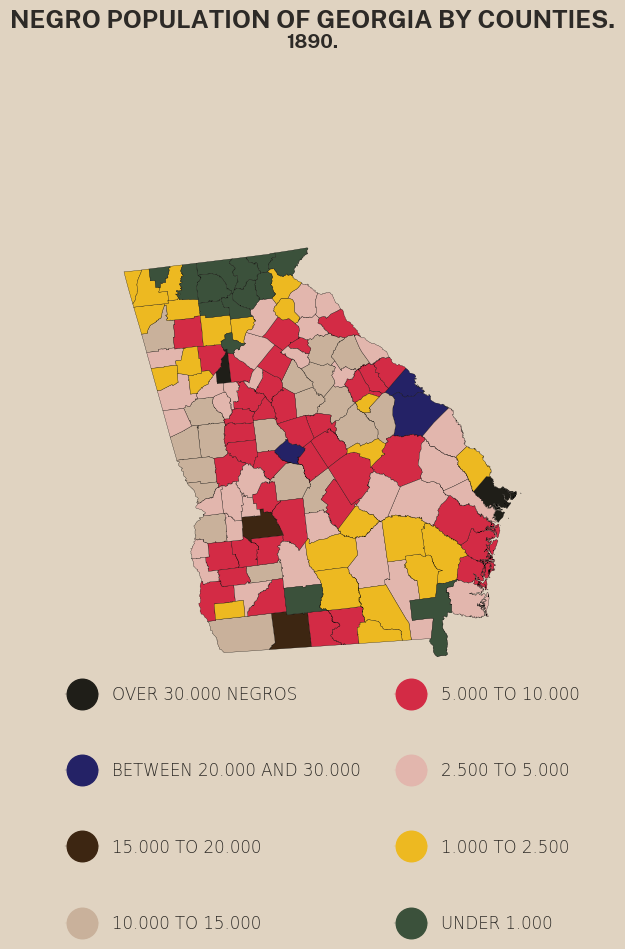

In [44]:
title = "NEGRO POPULATION OF GEORGIA BY COUNTIES."
subtitle = "1890."

# Custom font
font = load_google_font("Public Sans", weight="bold")

# Create figure
fig, ax = plt.subplots(figsize=(8, 10))

# Adjust spacing 
plt.subplots_adjust(top=0.75, bottom=0.3)

# Plot Georgia map
gdf.plot(ax=ax, facecolor=gdf["color"], ec="black", lw=0.2)

## Legend
# Custom circle markers for the legend
handles = [Line2D([], [], marker="o", linewidth=0.2, color=row["color"], label=row["Population"], markerfacecolor=row["color"], markersize=22)          
           for i, row in gdf.drop_duplicates(subset="Population").iterrows()]

# Add legend with 2 columns 
legend = ax.legend(handles=handles, ncols=2, bbox_to_anchor=(0.5, -0.6), loc="lower center", columnspacing=2, 
          labelspacing = 3.5, fontsize="large", facecolor="#e0d3c1", frameon = False)

# Control text in legend
for text in legend.get_texts():
    text.set_alpha(0.8)
    text.set_color("black")    
    text.set_fontweight("light")   

# Remove the axis
ax.set_axis_off()

ax.set_facecolor("#e0d3c1")

# Background color
fig.set_facecolor("#e0d3c1")

# Add title and subtitle
fig.text(0.5, 0.95, title, alpha=0.8, font=font, size=18, ha="center")
fig.text(0.5, 0.93, subtitle, alpha=0.8, font=font, size=14, ha="center")

plt.show()

# Saving the figure
#plt.savefig("plate05.jpg")

In [40]:
import numpy as np
import matplotlib.image as mpimg
from PIL import Image

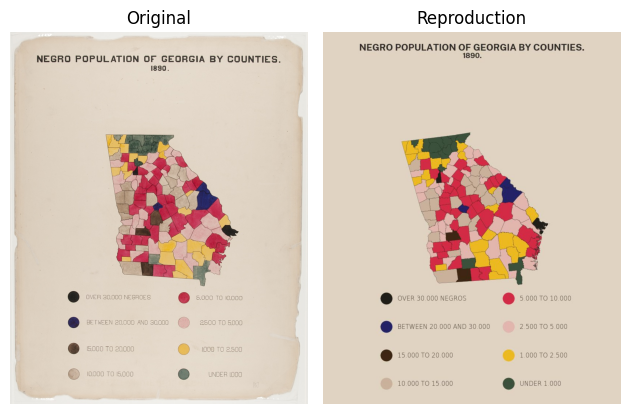

In [45]:
# Load images 
image1 = Image.open("original-plate-05.jpg")
image2 = Image.open("plate05.jpg")

# Convert to numpy arrays
images = [np.array(image1), np.array(image2)]
titles = ["Original", "Reproduction"]

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2)

# Loop through axes, images, and titles
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title)

# Adjust the layout and show
plt.tight_layout()
plt.show()

# Save the combined figure 
#plt.savefig("plate05sidebyside.png", dpi=300)